<a href="https://colab.research.google.com/github/azharaul/ds-ml-learning-journey/blob/main/dog_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-class Dog Breed Classification
This notebook builds an end-to-end multi-class image classifier using TensorFlow and TensorFlow Hub

## 1. Problem

Identifying the breed of a dog given an image of a dog.

## 2. Data

The data were using is from kaggle's dog breed identification competition.

https://www.kaggle.com/competitions/dog-breed-identification/overview

## 3. Evaluation

The evaluation is a file with prediction probabilities for each dog breed of each test image.

## 4. Features

Some information about the data:
*   Unstructured data (images)
*   There are 120 breeds of dogs (120 different classes)
* There are around 10,000+ images in the training set (have labels)
* There are around 10,000+ images in the test set (no labels)



In [1]:
# # Unzip data
# !unzip 'drive/MyDrive/Projects/Deep Learning/Dog Vision/dog-breed-identification.zip' -d 'drive/MyDrive/Projects/Deep Learning/Dog Vision/'

Streaming output truncated to the last 5000 lines.
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83bcff6b55ee179a7c123fa6103c377a.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83be6d622ab74a5e7e08b53eb8fd566a.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83c2d7419b0429b9fe953bc1b6cddbec.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83cf7d7cd2a759a93e2ffd95bea9c6fb.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83d405858f0931722ef21e8ac0adee4d.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83d4125a4c3c7dc5956563276cb1cd74.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83f0bb565b2186dbcc6a9d009cb26ff2.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83fad0718581a696132c96c166472627.jpg  
  inflating: drive/MyDrive/Projects/Deep Learning/Dog Vision/train/83fbbcc9a612e3f712b1ba199da61f20.j

### Setup Workspace


*   Import TensorFlow
*   Import TensorFlow Hub



In [2]:
# Import Tools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
print("TF Version", tf.__version__)
print("TF Hub Version", hub.__version__)

# Check GPU availability
print('GPU', 'available' if tf.config.list_physical_devices('GPU') else 'not available')

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TF Version 2.20.0
TF Hub Version 0.16.1
GPU available


### Import data

In [3]:
labels_csv = pd.read_csv('drive/MyDrive/Projects/Deep Learning/Dog Vision/labels.csv')
labels_csv.shape

(10222, 2)

In [4]:
labels_csv.describe()

,id,breed
count,10222,10222
unique,10222,120
top,fff43b07992508bc822f33d8ffd902ae,scottish_deerhound
freq,1,126


In [5]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [6]:
labels_csv['breed'].value_counts()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114
...,...
golden_retriever,67
komondor,67
brabancon_griffon,67


In [7]:
labels_csv['breed'].value_counts().median()

82.0

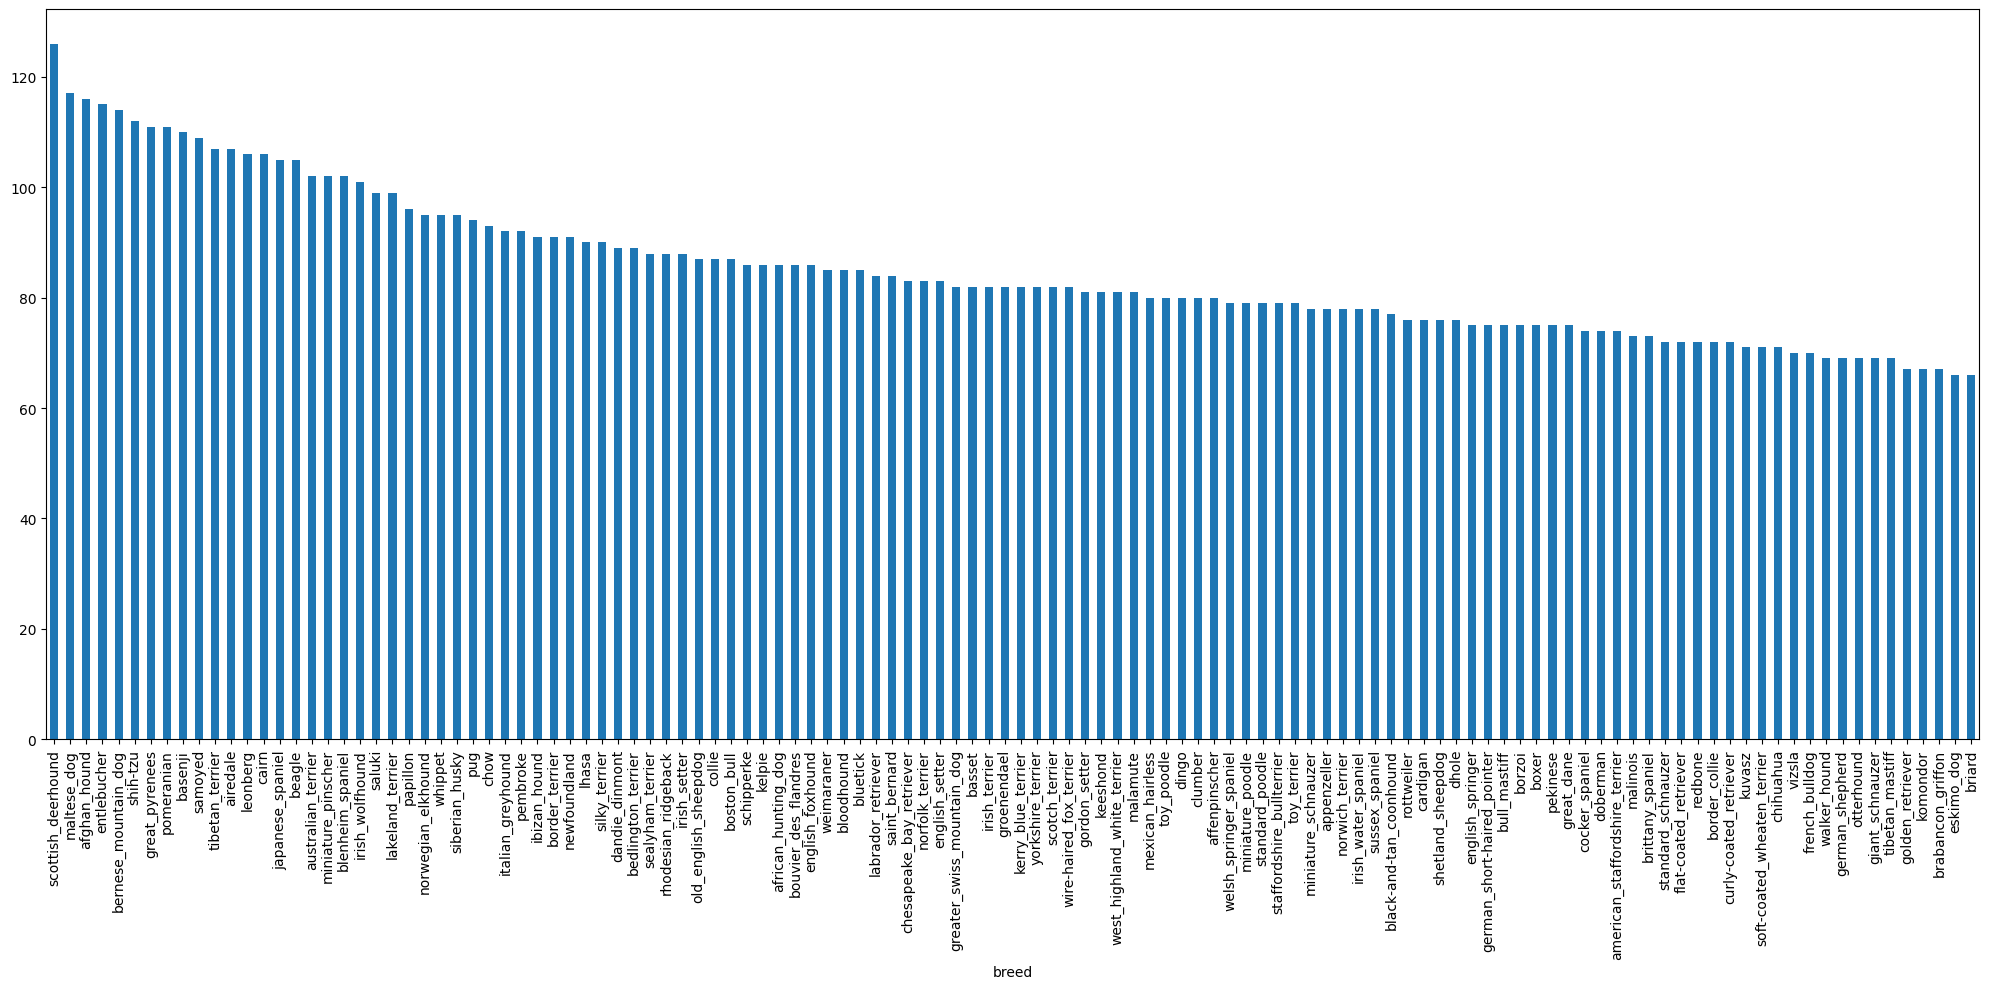

In [8]:
labels_csv['breed'].value_counts().plot.bar(figsize=(20,10))
plt.tight_layout()

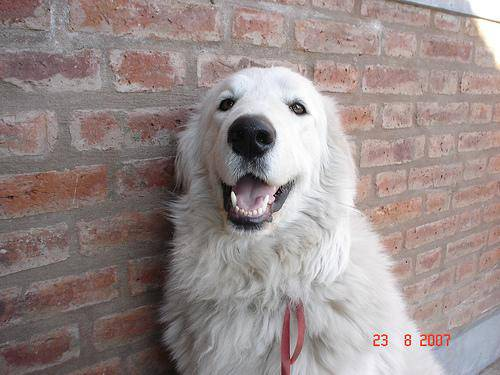

In [9]:
from IPython.display import Image
Image('/content/drive/MyDrive/Projects/Deep Learning/Dog Vision/train/0a0c223352985ec154fd604d7ddceabd.jpg')

### Getting images and their labels

In [10]:
# Create pathnames from images ID's
filenames = ['drive/MyDrive/Projects/Deep Learning/Dog Vision/train/' + fname + '.jpg' for fname in labels_csv['id']]
filenames[:10]

['drive/MyDrive/Projects/Deep Learning/Dog Vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/001cdf01b096e06d78e9e5112d419397.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/002a283a315af96eaea0e28e7163b21b.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 'drive/MyDrive/Projects/Deep Learning/Dog Vision/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [11]:
import os
os.listdir('drive/MyDrive/Projects/Deep Learning/Dog Vision/train/')[:10]

['000bec180eb18c7604dcecc8fe0dba07.jpg',
 '001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '001cdf01b096e06d78e9e5112d419397.jpg',
 '00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '002211c81b498ef88e1b40b9abf84e1d.jpg',
 '00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '002a283a315af96eaea0e28e7163b21b.jpg',
 '003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '0042188c895a2f14ef64a918ed9c7b64.jpg']

In [12]:
len(os.listdir('drive/MyDrive/Projects/Deep Learning/Dog Vision/train/')), len(filenames)

(10222, 10222)

In [13]:
# Check number of filenames mathces number of actual image files
if len(os.listdir('drive/MyDrive/Projects/Deep Learning/Dog Vision/train/')) == len(filenames):
  print('Filenames match')
else:
  print('filenames not match')

Filenames match


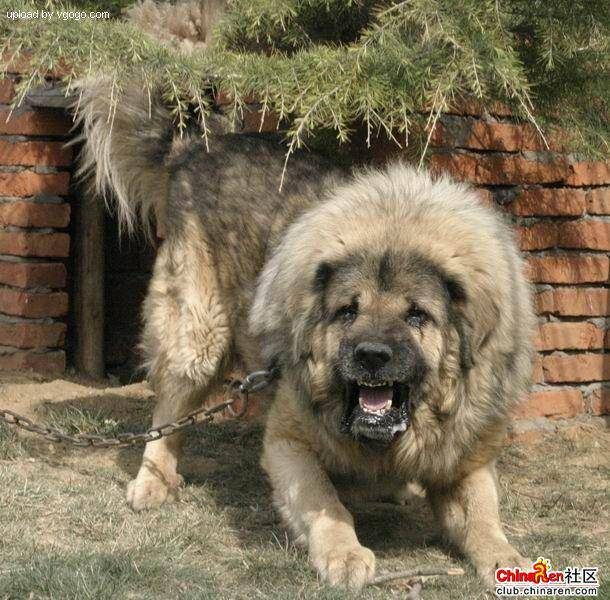

In [15]:
Image(filenames[9000])

In [17]:
labels_csv['breed'][9000]

'tibetan_mastiff'

In [20]:
import numpy as np
labels = labels_csv['breed'].to_numpy()
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [23]:
len(labels), len(filenames)

(10222, 10222)

In [26]:
# Find the unique label value
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [27]:
len(unique_breeds)

120

In [28]:
# Turn a single label into an array of booleans
print(labels[0])
labels[0] == unique_breeds

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [29]:
# Turn all label into boolean array
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [30]:
len(boolean_labels)

10222

### Creating validation set

In [31]:
X = filenames
y = boolean_labels

In [32]:
# Set number of images for experimenting
NUM_IMAGES = 1000 #@param {type:'slider', min:1000, max:10000, step:1000}

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES], y[:NUM_IMAGES], test_size=0.2, random_state=42)

len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)